In [1]:
import os
import torch
import numpy as np
from matplotlib import pyplot as plt
from wavediffusion.wavedata import npyDataWndHist
from torch.utils.data import DataLoader
from wavediffusion.model import Scaled, PredX0
from wavediffusion.model_unet import myUnet
from wavediffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, samples
from accelerate import Accelerator
from torch_ema import ExponentialMovingAverage as EMA
from torchvision import transforms as tf
import cartopy.crs as ccrs
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

In [2]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
stats_file1 = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file1)
meanf, stdf = stats['meanf'], stats['stdf']
stats_file2 = os.path.join(train_file_path, 'stats_parts.npz')
stats_parts = np.load(stats_file2)
meanx, stdx = stats_parts['meanparts'], stats_parts['stdparts']

In [3]:
month = 6

# Files for climatology
data_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
data_file_names = [(f'waveparts_{i:04d}{month:02d}', f'forcing_{i:04d}{month:02d}') for i in range(2010,2015)]
data_file_list = [(os.path.join(data_file_path, f'{x}.npy'), 
                   os.path.join(data_file_path, f'{f}.npy')) for x, f in data_file_names]
data = npyDataWndHist(
    data_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(data_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=3
)

# File for testing
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [(f'waveparts_{i:04d}{month:02d}', f'forcing_{i:04d}{month:02d}') for i in range(2004, 2005)]
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataWndHist(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(data_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=3
)

In [4]:
print('Computing climatological maps...')
clim_meanx, clim_stdx, clim_meanf, clim_stdf = data.compute_clim_map()
from wavediffusion.waveana import add_lat_lon 
ds_clim = add_lat_lon (clim_meanx[6:], ['cf'])

Computing climatological maps...


Text(0.5, 1.0, 'Climatology')

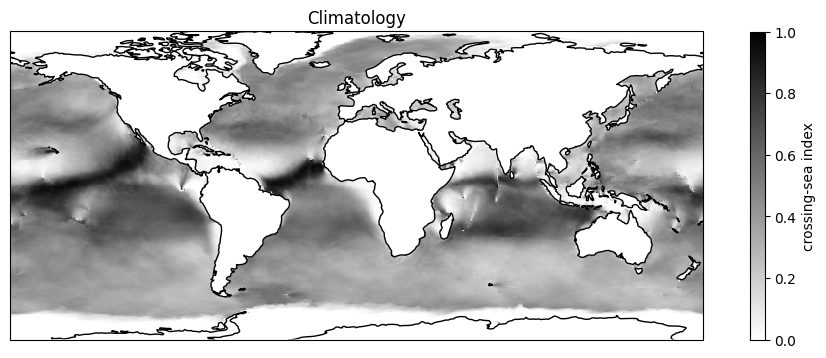

In [5]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[12,4])
ds_clim.cf.plot(ax=ax, vmax=1, vmin=0, cmap='binary', transform=ccrs.PlateCarree(), cbar_kwargs={'label':'crossing-sea index'})
ax.coastlines()
plt.title('Climatology')

### Load model

In [6]:
RESUME = True 
epoch = 8
path = '/global/homes/j/jiarongw/scratch_folder/log1p/waveparts_hist_PredX0/'
weights_file = path + f'ckpt_{epoch}.pt'
model = PredX0(Scaled(myUnet))(in_dim=320, in_ch=7, out_ch=7, ch=256, precond_ch=13, 
                       scale=(test.meanx, test.stdx, test.meanf, test.stdf),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))  

ema = EMA(model.parameters(), decay=0.999)
if RESUME:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])
a = Accelerator()
model, test = a.prepare(model, test)
ema.to(a.device)

############## Define sampling parameters ###########
schedule_infer = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=80)

### Compute Brier Score (BS) and Brier Skill Score (BSS)

In [54]:
# Weights computed and saved with wavedata.ipynb
mask = test.landmask == 1 # land mask for computing metrics
wlat = np.load('/global/homes/j/jiarongw/scratch_folder/wave_data/wlat.npy')
# weighted and masked RMSE
def weighted_mse(a, b, mask, w):
    diff2 = (a - b) ** 2
    return np.sum(diff2[mask] * w[mask]) / np.sum(w[mask])
# weighted and masked spread / skill
def weighted_meanvar(std, mask, w):
    var = std ** 2
    return np.sum(var[mask] * w[mask]) / np.sum(w[mask])

In [61]:
BS_sample = []
BS_onestep = []
BS_clima = []

for index in tqdm(range(0, test.__len__(), 4)):
    print(f'Sampling for index {index}...')
    x, f, icymask = test.__getitem__(index)
    x = x.unsqueeze(0).to(a.device); f = f.unsqueeze(0).to(a.device); icymask = icymask.unsqueeze(0).to(a.device)
    # Model predictions
    with torch.no_grad():
        with ema.average_parameters():
            # Multi-step sampling
            *xt, x0 = samples(
                model, schedule_infer.sample_sigmas(40), gam=1, mu=0.5, batchsize=1, 
                accelerator=a, cond=f, mask=icymask,
            )
            x_sample = test.invert_x(x0[0]) * tf.Resize((320,720))(icymask[0].to(x0))
            x_sample = x_sample.cpu().numpy()
            # One-step sampling for conditional mean
            sigma0 = schedule_infer.sample_sigmas(40)[0].to(a.device)
            xt = model.rand_input(1).to(a.device) * sigma0 * icymask.to(a.device)
            eps = model.predict_eps(xt, sigma0, cond=f) * icymask.to(a.device)
            x0 = xt - eps * sigma0
            x_onestep = test.invert_x(x0[0]) * tf.Resize((320,720))(icymask[0].to(x0))
            x_onestep = x_onestep.cpu().numpy()
        
    x_truth = test.invert_x(x[0]) * tf.Resize((320,720))(icymask[0].to(x)); x_truth = x_truth.cpu().numpy()
    # Lower bound the wave length with 0?
    x_sample[-1] = np.maximum(x_sample[-1], 0); x_sample[-1] = np.minimum(x_sample[-1], 1)
    x_onestep[-1] = np.maximum(x_onestep[-1], 0); x_onestep[-1] = np.minimum(x_onestep[-1], 1)
    x_truth[-1] = np.maximum(x_truth[-1], 0); x_truth[-1] = np.minimum(x_truth[-1], 1)  
    BS_sample.append(weighted_mse(x_truth[-1], x_sample[-1], mask, wlat))
    BS_onestep.append(weighted_mse(x_truth[-1], x_onestep[-1], mask, wlat))
    BS_clima.append(weighted_mse(x_truth[-1], clim_meanx[-1], mask, wlat))

  0%|          | 0/50 [00:00<?, ?it/s]

Sampling for index 0...


  2%|▏         | 1/50 [00:03<02:44,  3.37s/it]

Sampling for index 4...


  4%|▍         | 2/50 [00:07<02:49,  3.52s/it]

...

 96%|█████████▌| 48/50 [02:46<00:06,  3.48s/it]

Sampling for index 192...


 98%|█████████▊| 49/50 [02:49<00:03,  3.46s/it]

Sampling for index 196...


100%|██████████| 50/50 [02:53<00:00,  3.47s/it]


In [64]:
print(f'Onestep BS: {np.array(BS_onestep).mean():.2f} \\pm {np.array(BS_onestep).std():.2f}')
print(f'Sampled BS: {np.array(BS_sample).mean():.2f} \\pm {np.array(BS_sample).std():.2f}')
print(f'Clima BS: {np.array(BS_clima).mean():.2f} \\pm {np.array(BS_clima).std():.2f}')

Onestep BS: 0.09 \pm 0.00
Sampled BS: 0.12 \pm 0.01
Clima BS: 0.16 \pm 0.01


In [ ]:
for index in tqdm(range(0, 180, 4)):
    x_truth = np.load(f'{path}truth_{index}.npy')
    x_mean = np.load(f'{path}pred_{index}.npy')
    forcing  = np.load(f'{path}forcing_{index}.npy')

    ds = xr.Dataset({
        'hs_truth': (('lat', 'lon'), x_truth[0]),
        'lp_truth': (('lat', 'lon'), x_truth[1]),        
        'hs_mean':  (('lat', 'lon'), x_mean[0]),
        'lp_mean':  (('lat', 'lon'), x_mean[1]),
        'ice':      (('lat', 'lon'), forcing[2]),
    }, coords={'lat': lat_deg, 'lon': lon_deg})
    snapshots.append(ds)

ds_all = xr.concat(snapshots, dim='snapshot')

In [35]:
schedule_infer = ScheduleLogLinear(sigma_min=0.01, sigma_max=40, N=80)
index = 0
print(f'Sampling for index {index}...')
x, f, icymask = test.__getitem__(index)
x = x.unsqueeze(0).to(a.device); f = f.unsqueeze(0).to(a.device); icymask = icymask.unsqueeze(0).to(a.device)
# Model predictions
with torch.no_grad():
    with ema.average_parameters():
        # Multi-step sampling
        *xt, x0 = samples(
            model, schedule_infer.sample_sigmas(40), gam=1, mu=0.5, batchsize=1, 
            accelerator=a, cond=f, mask=icymask,
        )
        x_sample = test.invert_x(x0[0]) * tf.Resize((320,720))(icymask[0].to(x0))
        x_sample = x_sample.cpu().numpy()
        # One-step sampling for conditional mean
        sigma0 = schedule_infer.sample_sigmas(40)[0].to(a.device)
        xt = model.rand_input(1).to(a.device) * sigma0 * icymask.to(a.device)
        eps = model.predict_eps(xt, sigma0, cond=f) * icymask.to(a.device)
        x0 = xt - eps * sigma0
        x_onestep = test.invert_x(x0[0]) * tf.Resize((320,720))(icymask[0].to(x0))
        x_onestep = x_onestep.cpu().numpy()
x_truth = test.invert_x(x[0]) * tf.Resize((320,720))(icymask[0].to(x)); x_truth = x_truth.cpu().numpy()
x_sample[-1] = np.maximum(x_sample[-1], 0); x_sample[-1] = np.minimum(x_sample[-1], 1)
x_onestep[-1] = np.maximum(x_onestep[-1], 0); x_onestep[-1] = np.minimum(x_onestep[-1], 1)
x_truth[-1] = np.maximum(x_truth[-1], 0); x_truth[-1] = np.minimum(x_truth[-1], 1)  

Sampling for index 0...


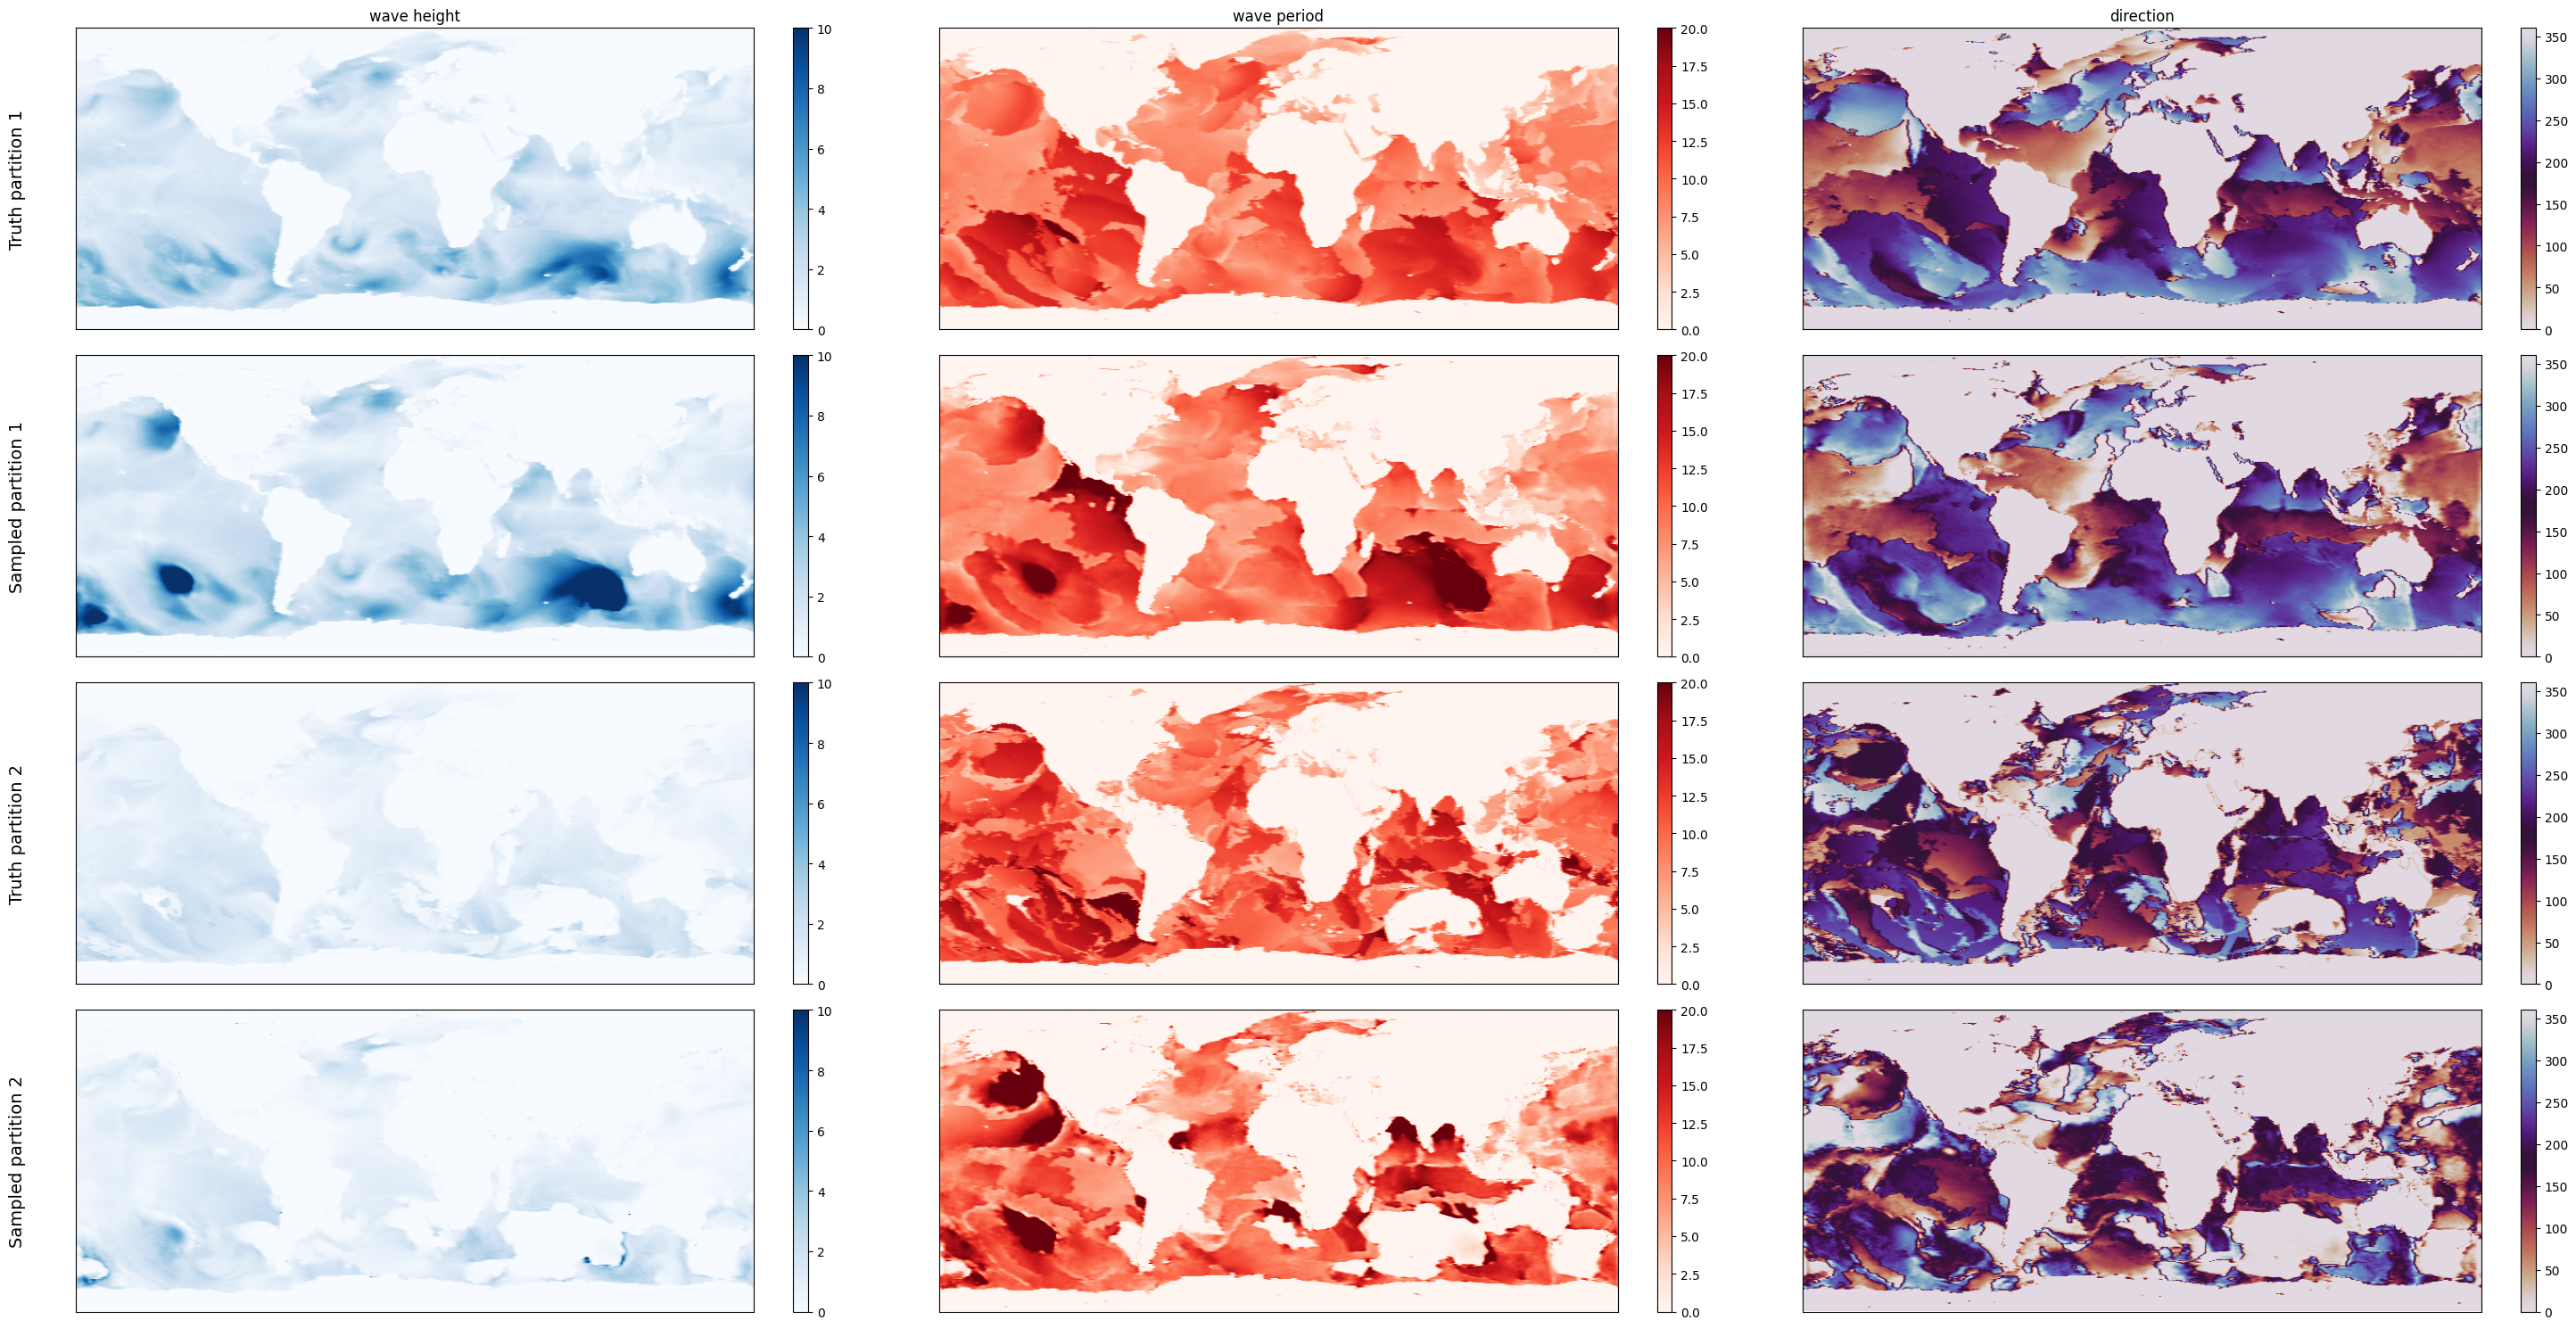

In [36]:
from wavediffusion.waveutils import plot_sample_parts
fig = plot_sample_parts(x_truth[:,::-1], x_sample[:,::-1])

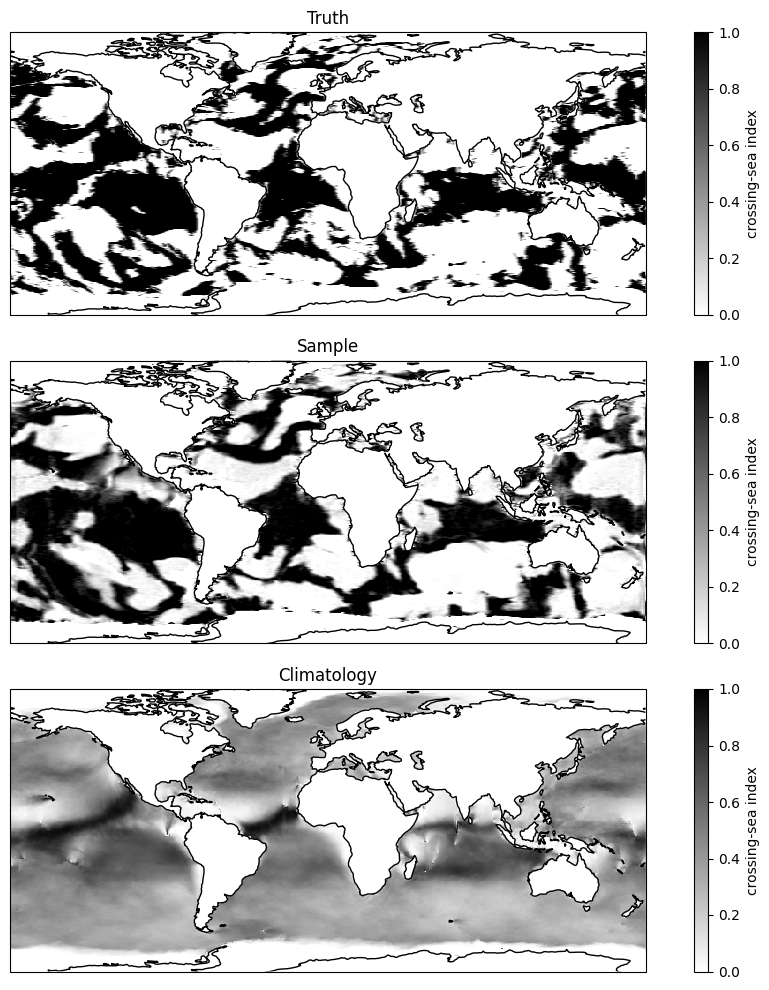

In [22]:
ds = add_lat_lon ([x_truth[-1], x_sample[-1], clim_meanx[-1]], ['cf_truth', 'cf_sample','cf_clima'])
fig, axes = plt.subplots(3, 1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10, 10], dpi=100)
ds.cf_truth.plot(ax=axes[0], vmax=1, vmin=0, cmap='binary', transform=ccrs.PlateCarree(), cbar_kwargs={'label':'crossing-sea index'})
ds.cf_sample.plot(ax=axes[1], vmax=1, vmin=0, cmap='binary', transform=ccrs.PlateCarree(), cbar_kwargs={'label':'crossing-sea index'})
ds.cf_clima.plot(ax=axes[2], vmax=1, vmin=0, cmap='binary', transform=ccrs.PlateCarree(), cbar_kwargs={'label':'crossing-sea index'})
axes[0].coastlines(); axes[1].coastlines(); axes[2].coastlines()
axes[0].set_title('Truth'); axes[1].set_title('Sample'); axes[2].set_title('Climatology')
plt.tight_layout()

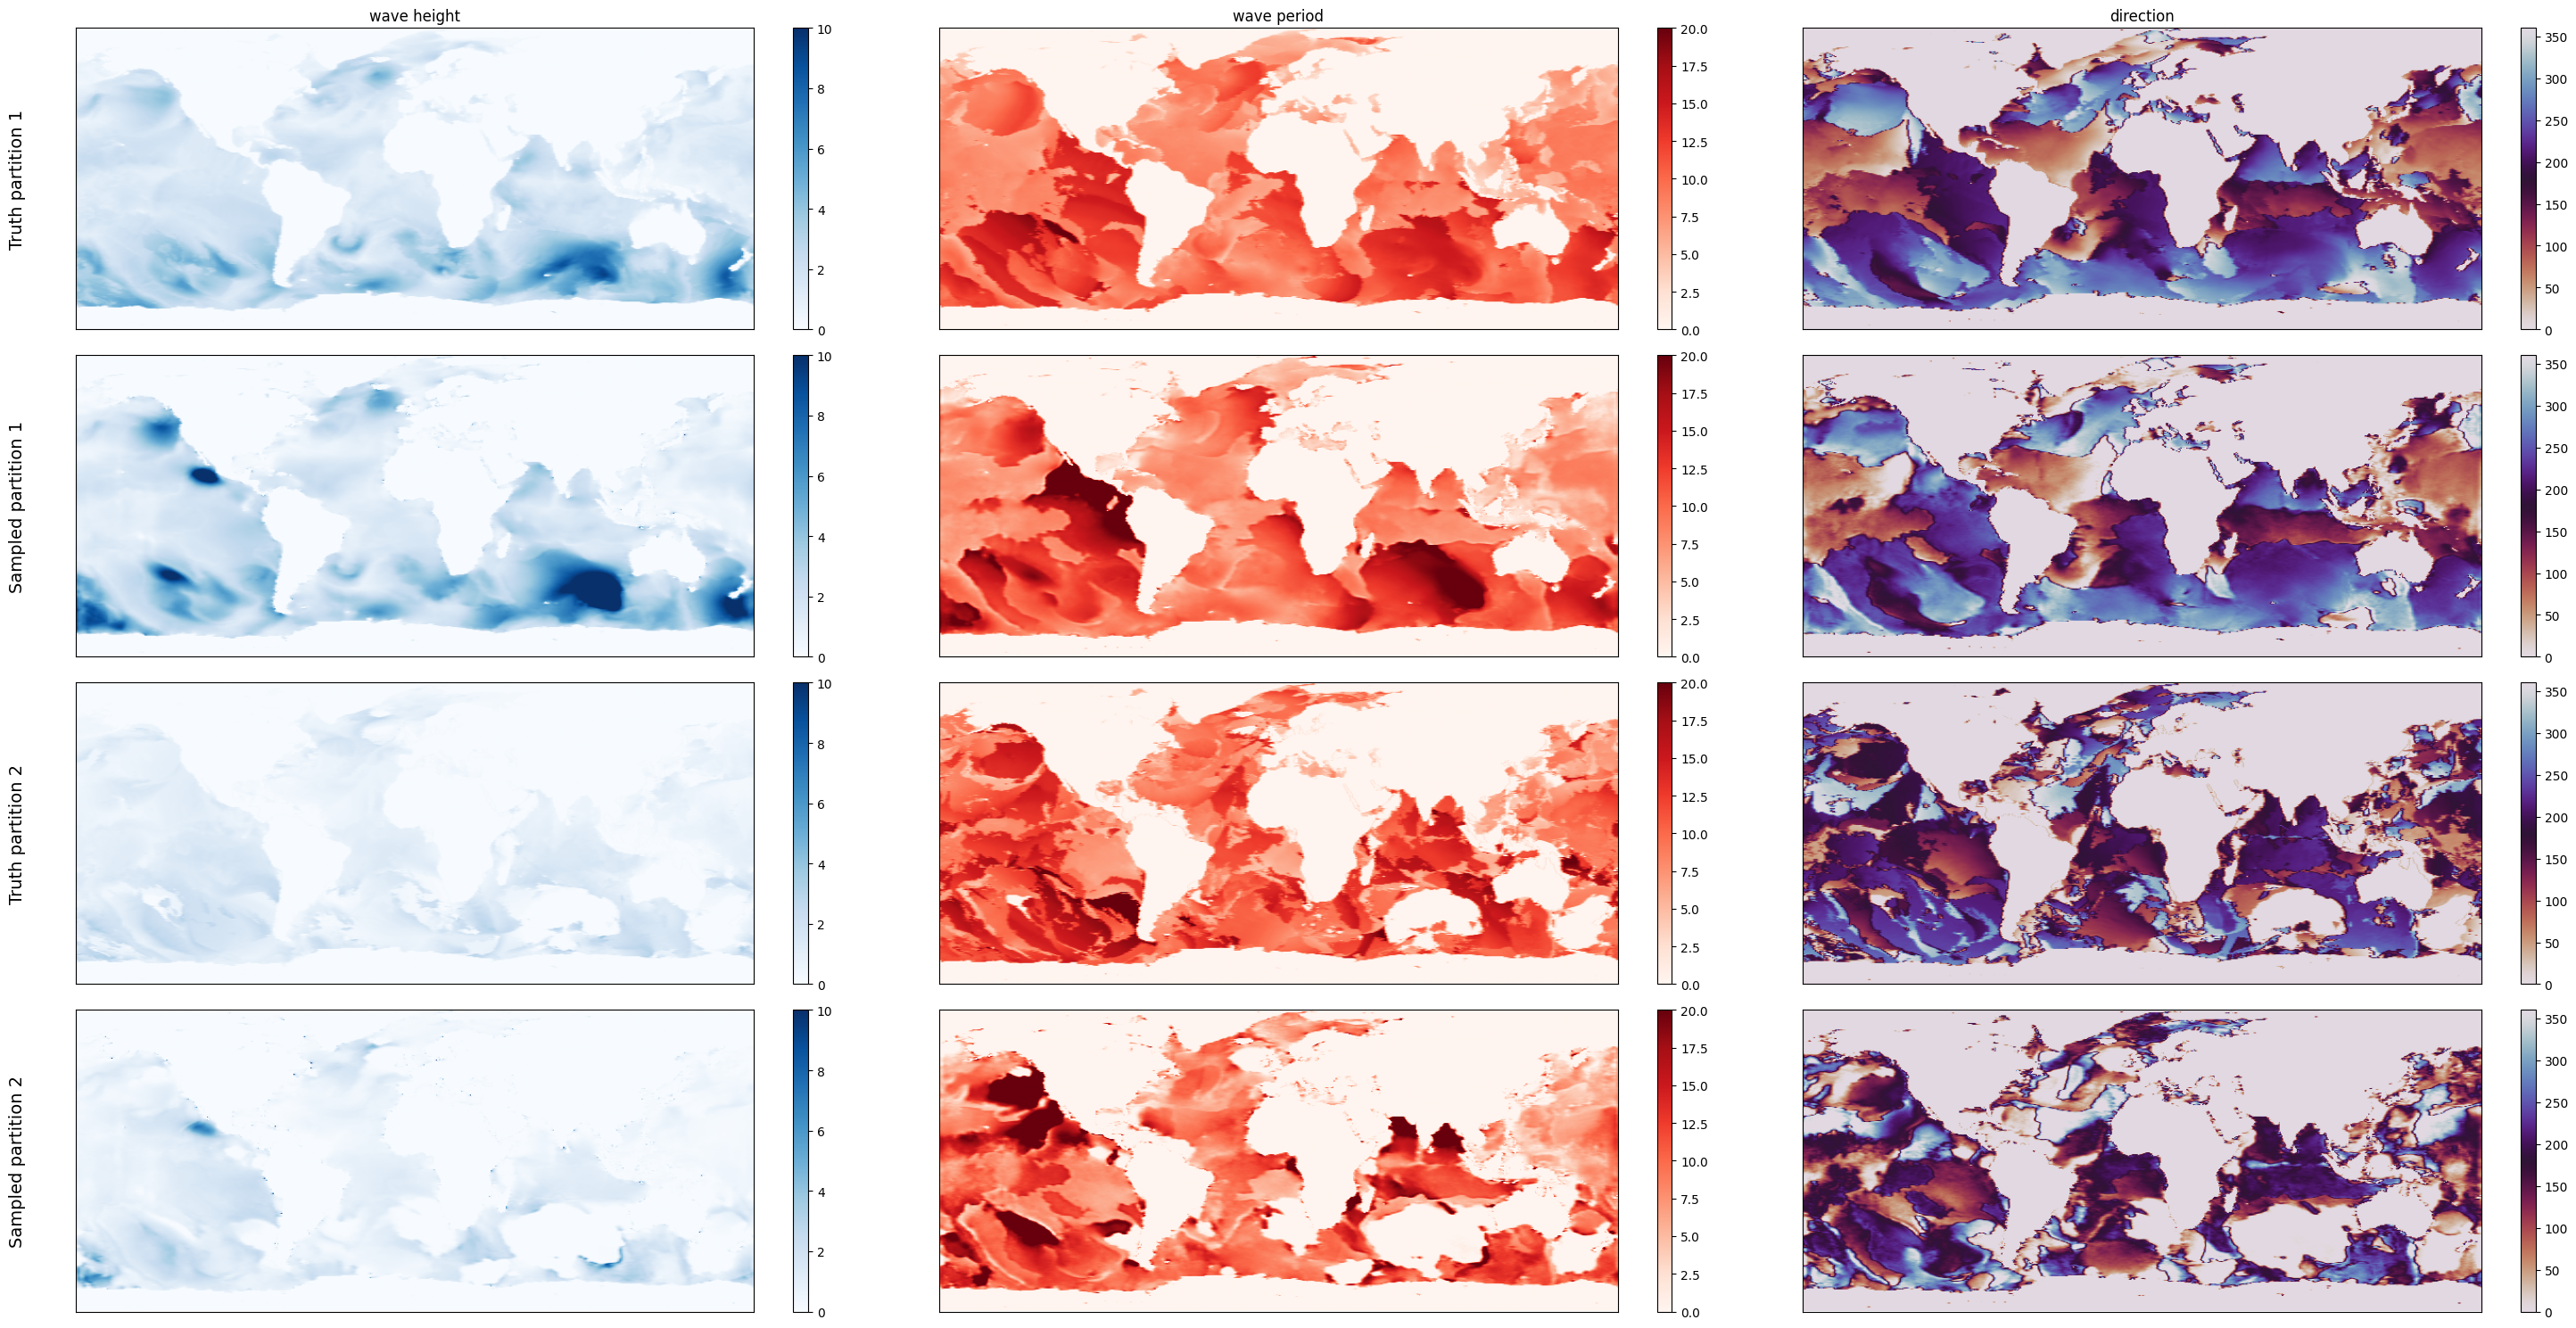

In [27]:
from wavediffusion.waveutils import plot_sample_parts
fig = plot_sample_parts(x_truth[:,::-1], x_sample[:,::-1])